In [57]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# --- Data Loading (optimized) ---
def load_ecobici_data(base_path="datasets", years=None, sample_size=None):
    base = Path(base_path)
    files = base.glob("**/*.csv")
    dfs = []
    for f in files:
        if sample_size:
            total = sum(1 for _ in open(f)) - 1
            frac = sample_size / total if total>0 else 1
            df = pd.read_csv(f, encoding='latin-1', skiprows=lambda i: i>0 and np.random.rand()>frac)
        else:
            df = pd.read_csv(f, encoding='latin-1')
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(data):,} rows from {len(dfs)} files.")
    return data

# --- Stations Loading ---
def load_stations(path="datasets/stations.csv"):
    stations = pd.read_csv(path, encoding='latin-1')
    stations['id'] = pd.to_numeric(stations['id'], errors='coerce').astype('Int64')
    print(f"Loaded {len(stations)} stations.")
    return stations

# --- Exploration ---
def explore(df):
    print(df.info())
    print(df.describe().T)
    print(df.isnull().sum())

# --- Preprocessing (concise + robust) ---
def preprocess(df):
    df = df.dropna(subset=['Fecha_Retiro','Hora_Retiro','Fecha_Arribo','Hora_Arribo'])
    df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Retiro'] + ' ' + df['Hora_Retiro'], dayfirst=True, errors='coerce')
    df['Fecha_Hora_Arribo'] = pd.to_datetime(df['Fecha_Arribo'] + ' ' + df['Hora_Arribo'], dayfirst=True, errors='coerce')
    df['Duracion_Minutos'] = (df['Fecha_Hora_Arribo'] - df['Fecha_Hora_Retiro']).dt.total_seconds() / 60
    df = df.query('0 < Duracion_Minutos < 1440')
    df['Edad_Usuario'] = pd.to_numeric(df['Edad_Usuario'], errors='coerce').fillna(df['Edad_Usuario'].median())
    df['Genero_Cod'] = df['Genero_Usuario'].map({'M':0,'F':1}).fillna(2).astype(int)
    for col in ['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']:
        tmp = pd.to_numeric(df[col], errors='coerce')
        tmp = tmp.fillna(method='ffill')
        mode_vals = tmp.mode()
        fill_val = mode_vals.iloc[0] if not mode_vals.empty else 0
        tmp = tmp.fillna(fill_val)
        df[col] = tmp.astype('Int64')
    return df

# --- Main Execution ---
if __name__ == '__main__':
    df = load_ecobici_data(years=['2024','2025'], sample_size=50000)
    stations = load_stations()
    explore(df)
    processed = preprocess(df)
    print(f"Processed data shape: {processed.shape}")
    processed.to_csv('ecobici_processed.csv', index=False)
    print("Saved processed data to 'ecobici_processed.csv'.")


Loaded 8,747,381 rows from 178 files.
Loaded 480 stations.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8747381 entries, 0 to 8747380
Data columns (total 28 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     float64
 1   lat                    float64
 2   lon                    float64
 3   name                   object 
 4   Genero_Usuario         object 
 5   Edad_Usuario           float64
 6   Bici                   object 
 7   Ciclo_Estacion_Retiro  object 
 8   Fecha_Retiro           object 
 9   Hora_Retiro            object 
 10  Ciclo_Estacion_Arribo  float64
 11  Fecha_Arribo           object 
 12  Hora_Arribo            object 
 13  Unnamed: 9             float64
 14  ï»¿Genero_Usuario      object 
 15  BikeID                 float64
 16  Ciclo_EstacionArribo   object 
 17  Fecha Arribo           object 
 18  Hora Arribo            object 
 19  Hora_Retiro.1          object 
 20  Genero_usuario         object 


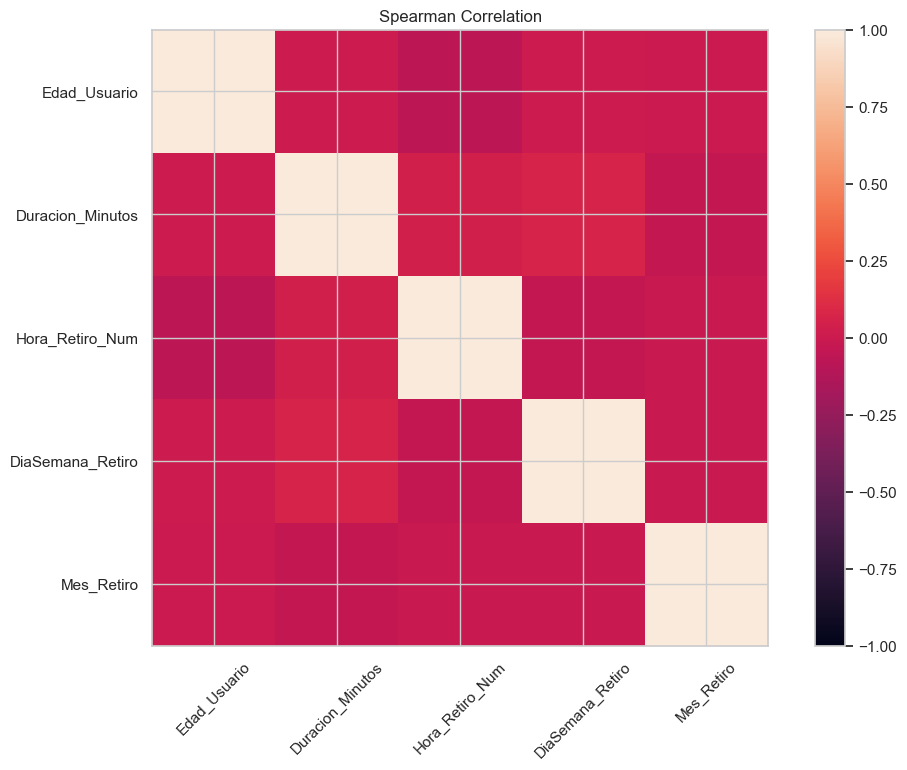

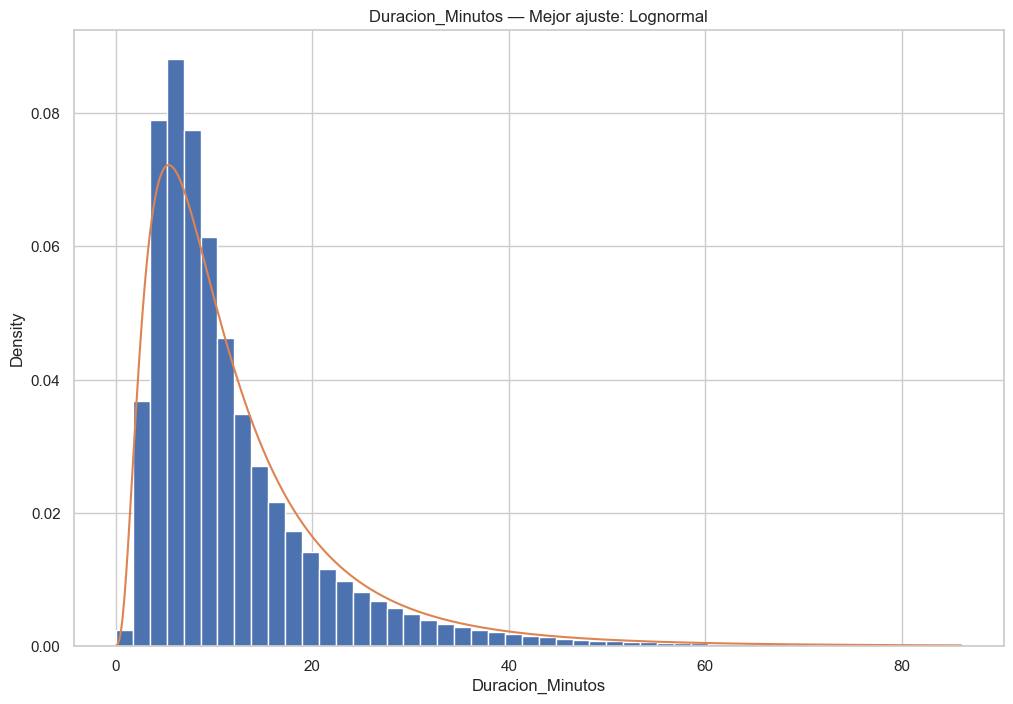

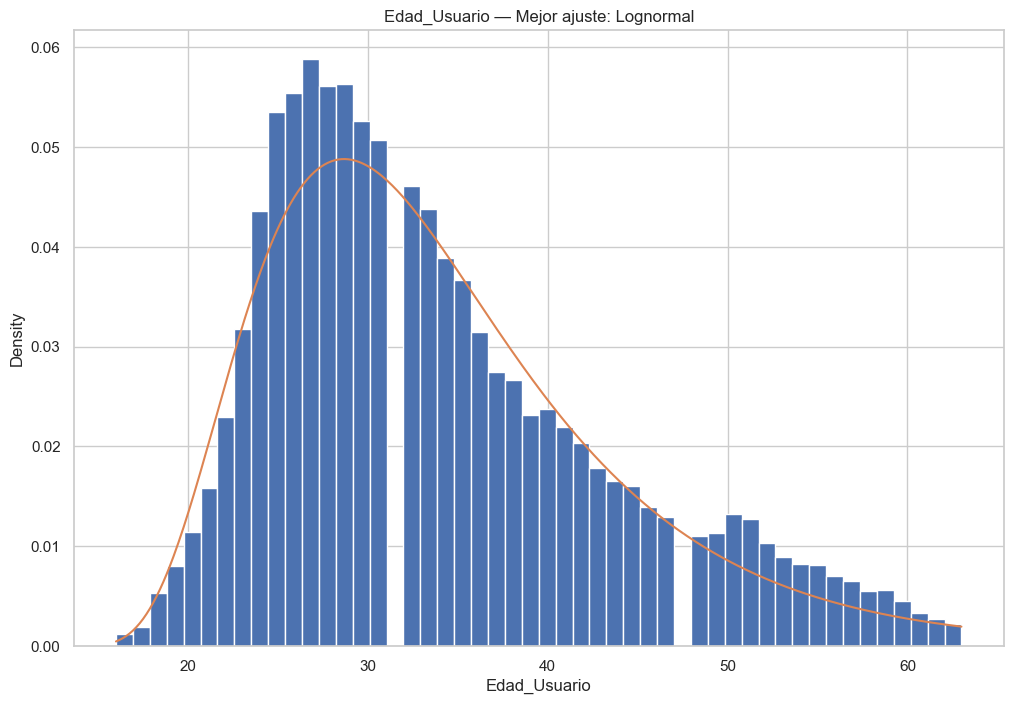

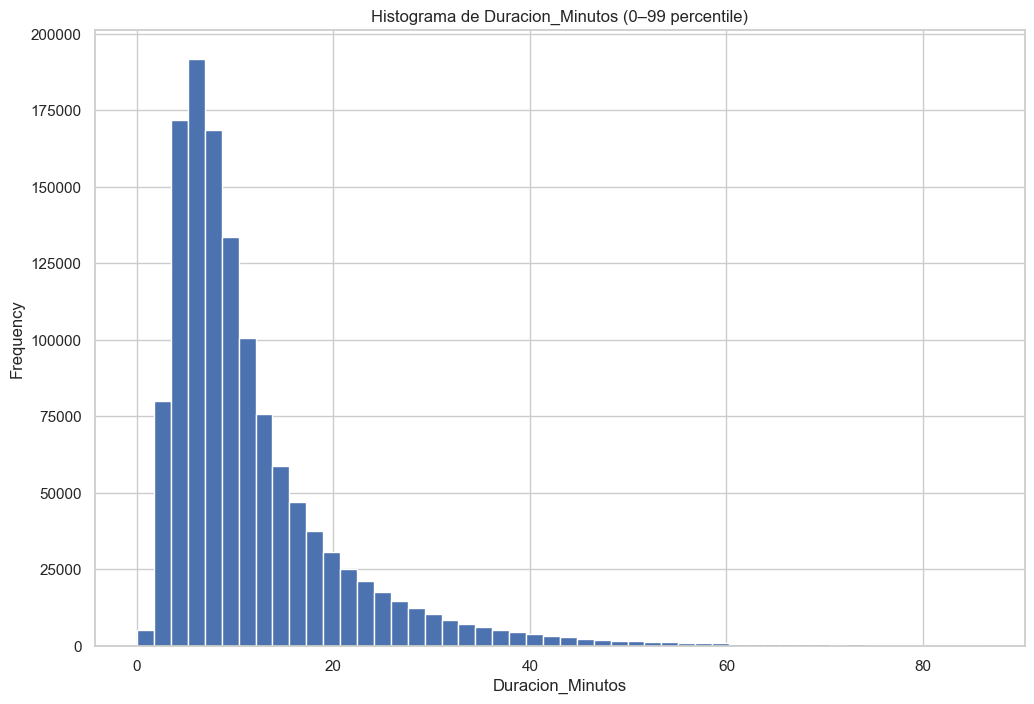

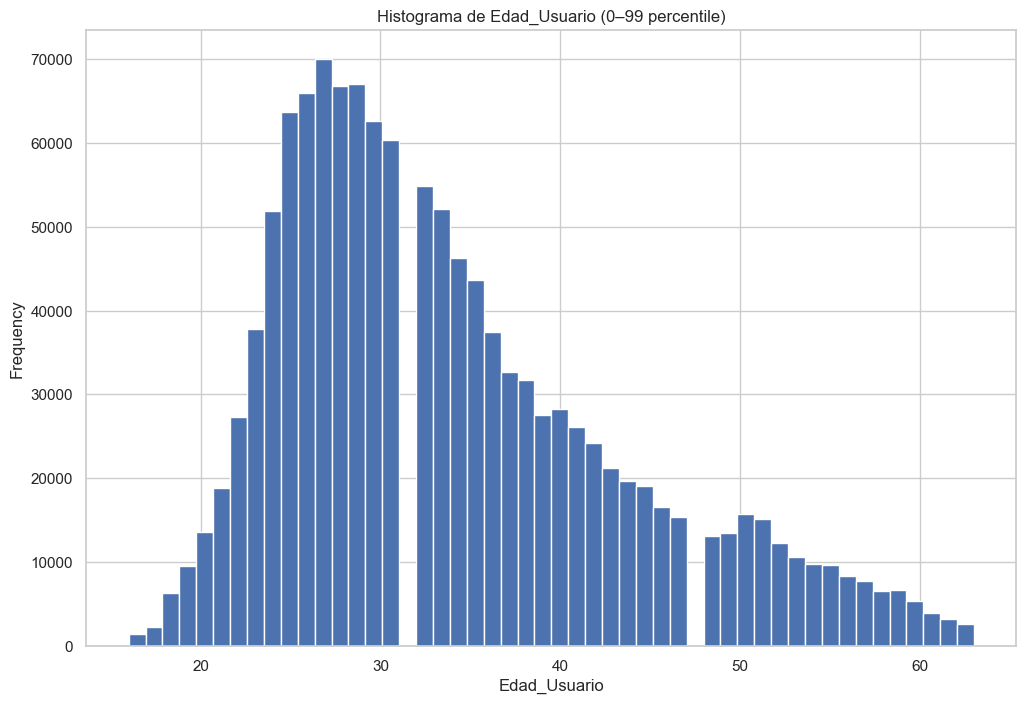

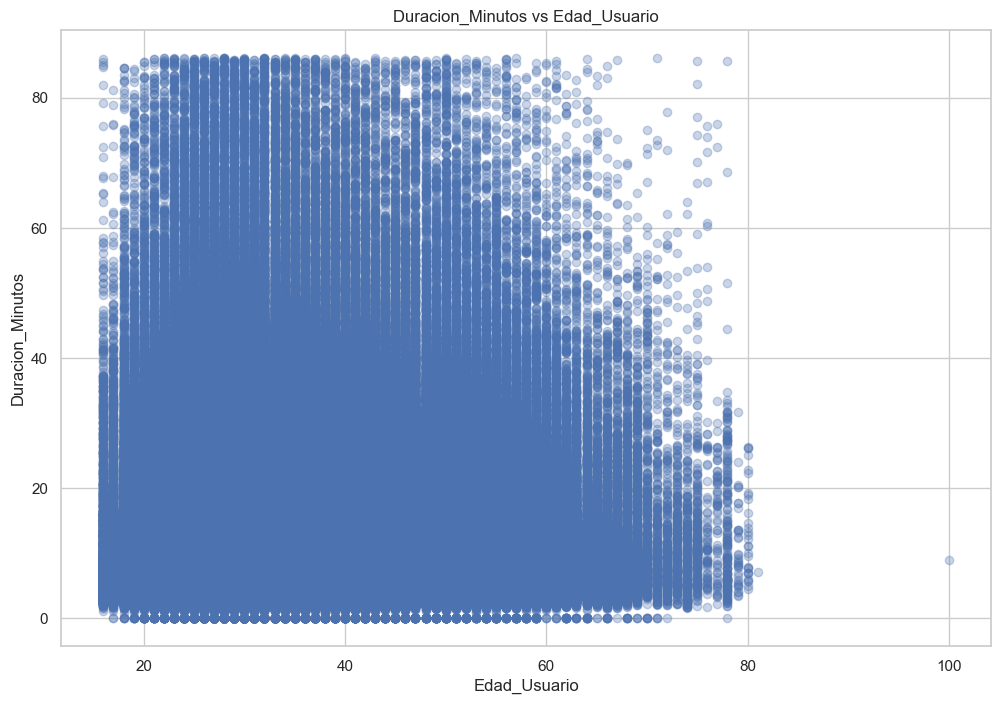

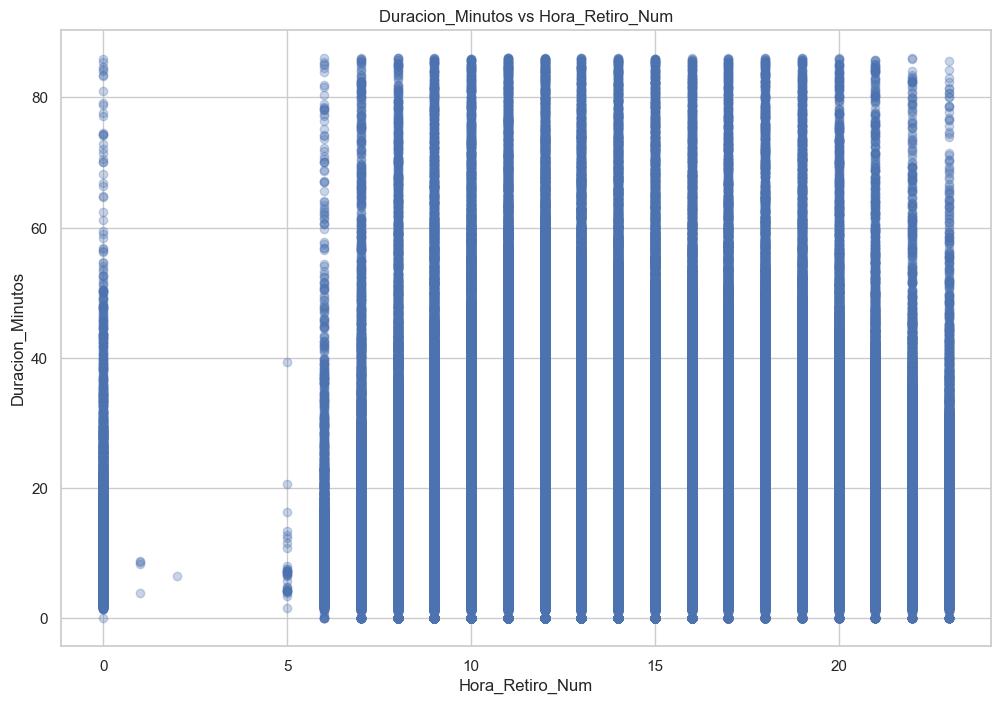

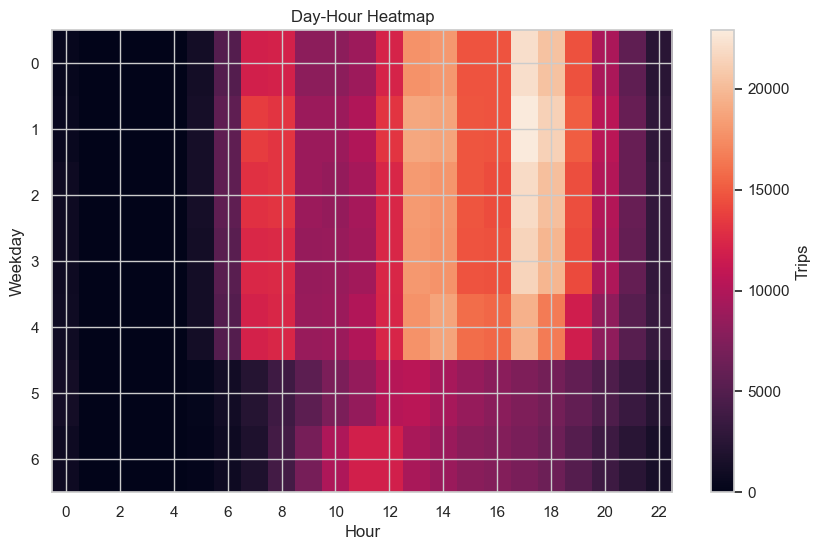

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.gofplots import qqplot

# Advanced Exploratory Analysis (filtered ranges)
def advanced_exploratory(df):
    # Ensure temporal features exist
    if 'Fecha_Hora_Retiro' in df.columns:
        df['Hora_Retiro_Num'] = df['Fecha_Hora_Retiro'].dt.hour
        df['DiaSemana_Retiro'] = df['Fecha_Hora_Retiro'].dt.dayofweek
        df['Mes_Retiro'] = df['Fecha_Hora_Retiro'].dt.month

    # Select numeric features present
    cols = [c for c in ['Edad_Usuario','Duracion_Minutos','Hora_Retiro_Num','DiaSemana_Retiro','Mes_Retiro'] if c in df.columns]
    df_num = df[cols].dropna()

    # Correlation matrix
    corr = df_num.corr(method='spearman')
    plt.figure()
    plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(cols)), cols, rotation=45)
    plt.yticks(range(len(cols)), cols)
    plt.title('Spearman Correlation')
    plt.show()

    # Distribution fitting & histograms trimmed to 99th percentile
    distributions = [('Normal', stats.norm), ('Lognormal', stats.lognorm), ('Gamma', stats.gamma), ('Exponential', stats.expon)]
    for var in ['Duracion_Minutos','Edad_Usuario']:
        if var in df_num:
            data = df_num[var]
            upper = data.quantile(0.99)
            x = np.linspace(data.min(), upper, 500)
            best = (None, None, np.inf)
            for name, dist in distributions:
                try:
                    params = dist.fit(data)
                    hist, bins = np.histogram(data[data<=upper], bins=50, density=True)
                    centers = (bins[:-1]+bins[1:])/2
                    sse = ((hist - dist.pdf(centers,*params))**2).sum()
                    if sse < best[2]: best = (name, dist.pdf(x,*params), sse)
                except:
                    continue
            plt.figure()
            plt.hist(data[data<=upper], bins=50, density=True)
            if best[0]: plt.plot(x, best[1])
            plt.title(f'{var} — Mejor ajuste: {best[0]}')
            plt.xlabel(var); plt.ylabel('Density')
            plt.show()

    # Histograms
    for var in ['Duracion_Minutos','Edad_Usuario']:
        if var in df_num:
            data = df_num[var]
            upper = data.quantile(0.99)
            plt.figure()
            plt.hist(data[data<=upper], bins=50)
            plt.title(f'Histograma de {var} (0–99 percentile)')
            plt.xlabel(var); plt.ylabel('Frequency')
            plt.show()

    # Scatter plots
    for x,y in [('Edad_Usuario','Duracion_Minutos'),('Hora_Retiro_Num','Duracion_Minutos')]:
        if x in df_num and y in df_num:
            data = df_num[df_num[y]<=df_num[y].quantile(0.99)]
            plt.figure()
            plt.scatter(data[x], data[y], alpha=0.3)
            plt.title(f'{y} vs {x}')
            plt.xlabel(x); plt.ylabel(y)
            plt.show()

    # Day-hour heatmap
    if {'DiaSemana_Retiro','Hora_Retiro_Num'}.issubset(df.columns):
        matrix = df.groupby(['DiaSemana_Retiro','Hora_Retiro_Num']).size().unstack(fill_value=0)
        plt.figure(figsize=(10,6))
        plt.imshow(matrix, aspect='auto')
        plt.colorbar(label='Trips')
        plt.title('Day-Hour Heatmap')
        plt.xlabel('Hour'); plt.ylabel('Weekday')
        plt.xticks(np.arange(0,24,2))
        plt.show()

df = pd.read_csv('ecobici_processed.csv', parse_dates=['Fecha_Hora_Retiro','Fecha_Hora_Arribo'])
advanced_exploratory(df)



Loaded 480 stations.


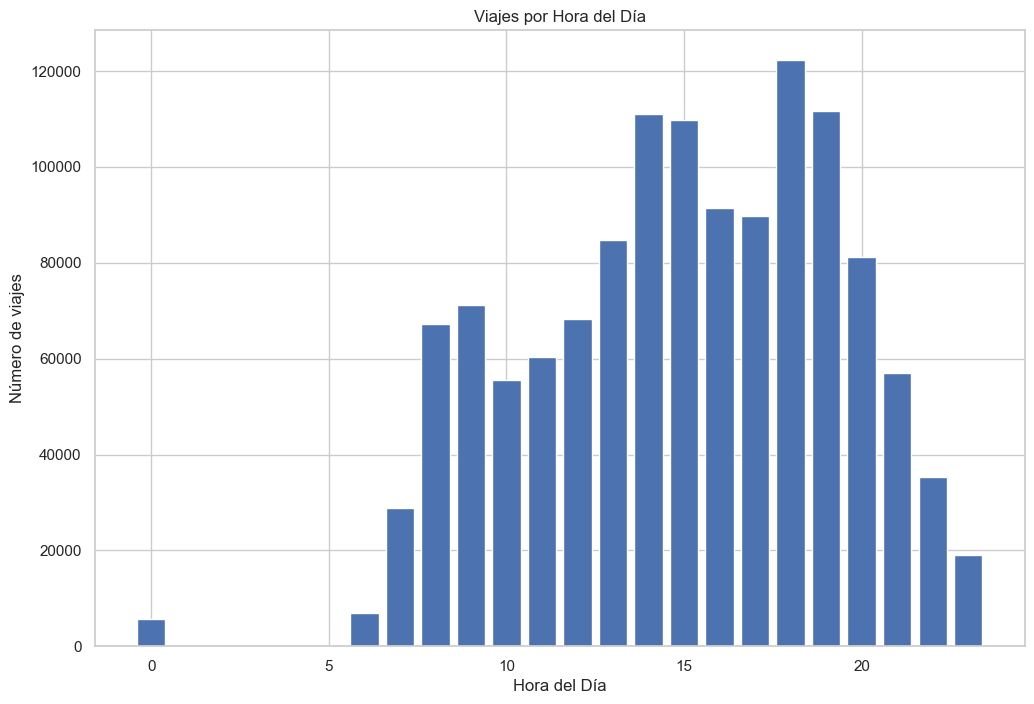

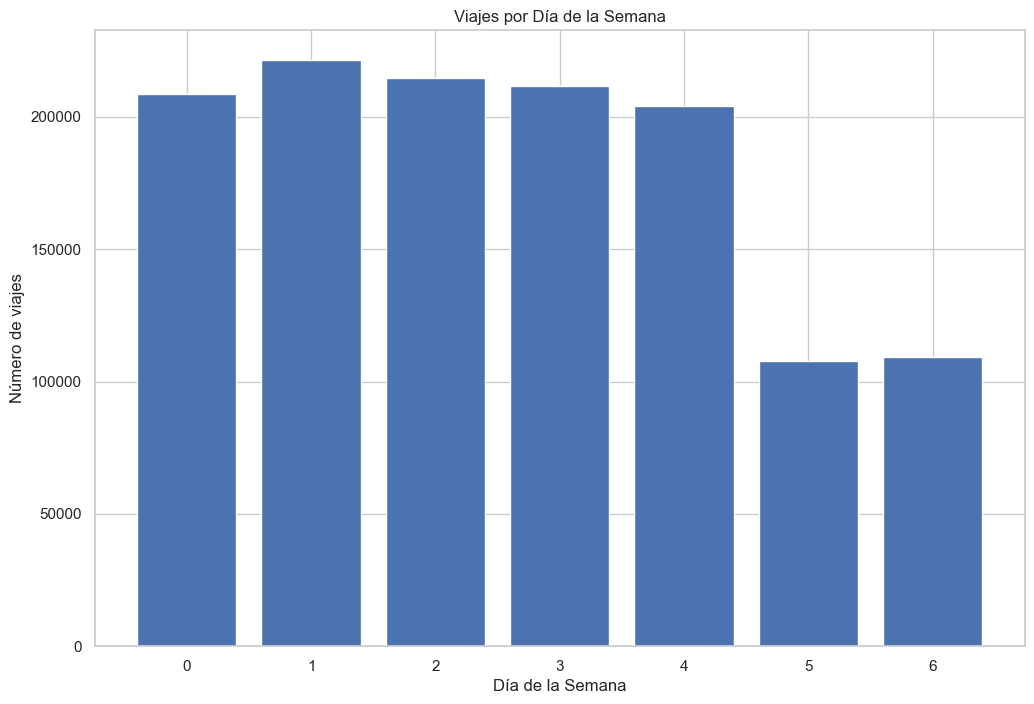

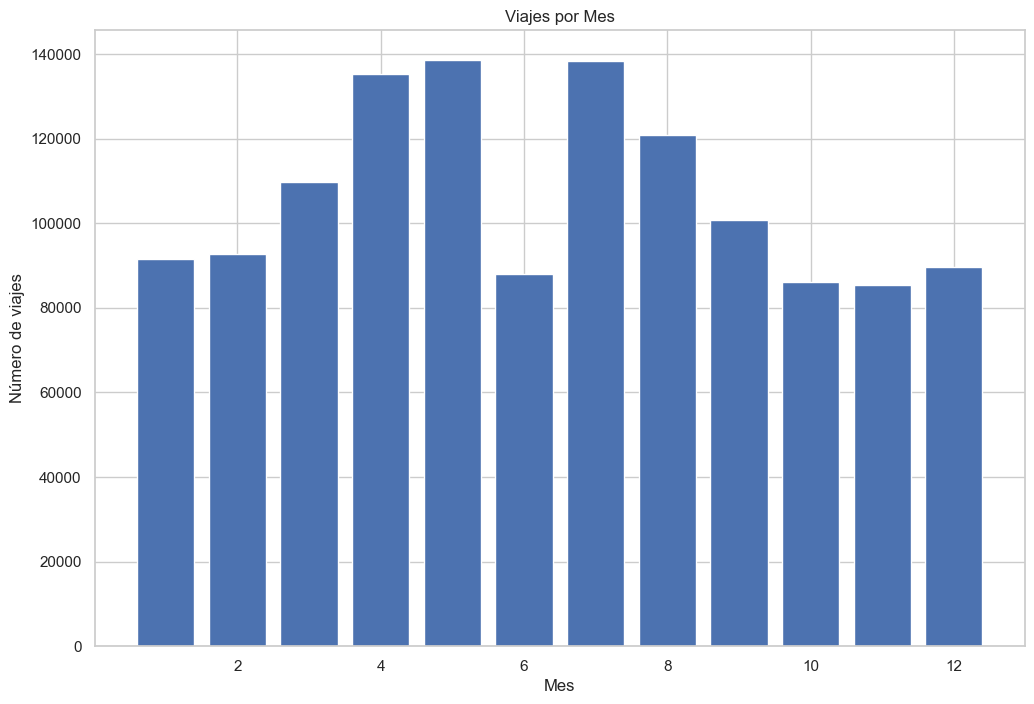

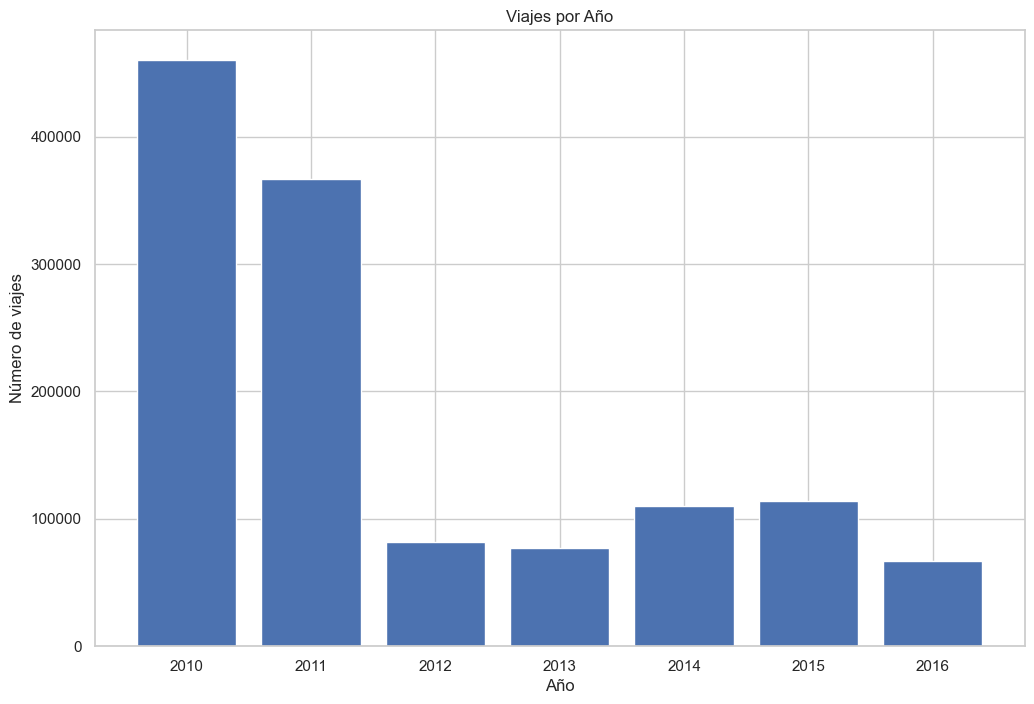

In [ ]:
import folium
from IPython.display import display

def spatio_temporal(df, stations):
    # Crear variables temporales
    df['Year'] = df['Fecha_Hora_Retiro'].dt.year
    df['Month'] = df['Fecha_Hora_Retiro'].dt.month
    df['DayOfWeek'] = df['Fecha_Hora_Retiro'].dt.dayofweek
    df['Hour'] = df['Fecha_Hora_Retiro'].dt.hour

    # 4.1 Patrones temporales (bar charts)
    for col, label in [('Hour','Hora del Día'), ('DayOfWeek','Día de la Semana'), 
                       ('Month','Mes'), ('Year','Año')]:
        counts = df[col].value_counts().sort_index()
        plt.figure()
        plt.bar(counts.index, counts.values)
        plt.title(f'Viajes por {label}')
        plt.xlabel(label)
        plt.ylabel('Número de viajes')
        plt.show()

    # 4.2 Mapeo de estaciones
    usage = df['Ciclo_Estacion_Retiro'].value_counts().add(
        df['Ciclo_EstacionArribo'].value_counts(), fill_value=0
    )
    stations['Total_Uses'] = stations['id'].map(usage).fillna(0)

    fmap = folium.Map(location=[19.4326, -99.1332], zoom_start=12)
    for _, row in stations.iterrows():
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=max(3, row.Total_Uses/2000),
            popup=f"{row.name}: {int(row.Total_Uses)} viajes"
        ).add_to(fmap)
    display(fmap)

    # 4.3 Visualización de flujos (top 50)
    flows = df.groupby(['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']).size().reset_index(name='count')
    flows = flows.dropna()
    top_flows = flows.sort_values('count', ascending=False).head(50)

    for _, r in top_flows.iterrows():
        try:
            orig = stations.set_index('id').loc[int(r.Ciclo_Estacion_Retiro)]
            dest = stations.set_index('id').loc[int(r.Ciclo_EstacionArribo)]
            folium.PolyLine(
                locations=[(orig.lat, orig.lon), (dest.lat, dest.lon)],
                weight=r['count']/2000,
                opacity=0.5
            ).add_to(fmap)
        except KeyError:
            continue

    display(fmap)

# Ejecución
stations_df = load_stations('datasets/stations.csv')
processed = pd.read_csv('ecobici_processed.csv', parse_dates=['Fecha_Hora_Retiro','Fecha_Hora_Arribo'])
spatio_temporal(processed, stations_df)
